<a href="https://colab.research.google.com/github/JimenezHAnaFer/MetodosN/blob/main/Distribuci%C3%B3n_Triangular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distribución Triangular

Una distribución triangular es una distribución continua que se describe por sus valores mínimos, máximos y su moda. La distribución tiene una forma triangular. Comienza en el valor mínimo, aumenta de manera lineal hasta alcanzar el valor pico en la moda y luego disminuye de manera lineal hasta alcanzar el valor máximo. La forma del triángulo puede ser simétrica o asimétrica.

**Función de densidad de probabilidad**


f(x) = \begin{cases}
    \frac{2(x-a)}{(b-a)(c-a)} & \text{si } a \le x \le b \\
    \frac{2(c-x)}{(c-a)(c-b)} & \text{si } b < x \le c
\end{cases}

**Función acumulativa**


F(x) = \begin{cases}
    \frac{(x-a)^2}{(c-a)(b-a)} & \text{si } a \le x \le b \\
    1 + \frac{(c-x)^2}{(c-a)(c-b)} & \text{si } b < x \le c
\end{cases}

Datos del programa:
La varianza es: 0.6659672427706907
La media es: 2.999073695152456
La desviacion es: 0.8160681606156993
Datos teoricos obtenidos:
La varianza es: 0.6666666666666666
La media es: 3.0
La desviacion es: 0.816496580927726


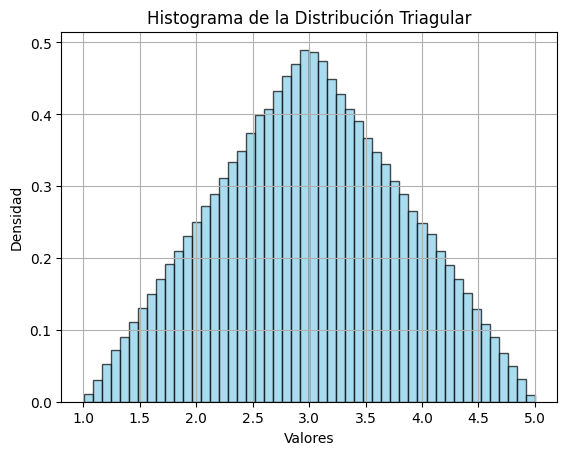

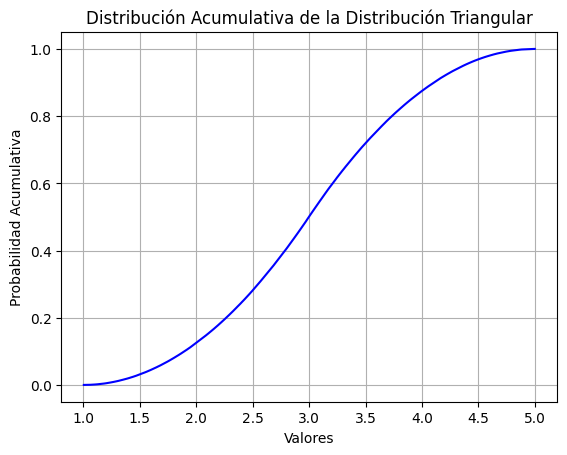

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd

# Parámetros de la distribución triangular
a = 1   # mínimo
b = 3  # moda
c = 5   # maximo
n=1000000  #cantidad de numeros aleatorios

resultados = []
# Función para generar valores con distribución triangular
def distribucion_triangular(a, b, c, n):

    for _ in range(n):
        r = rd.random() # genera un valor entre 0 y 1
        if r < (b-a)/(c-a):  # Zona izquierda (a ≤ x ≤ b): línea creciente    &    Zona derecha (b < x ≤ c): línea decreciente
            x = a + np.sqrt(r*(c-a)*(b-a))   #Función acomulativa (inversa)
        else:
            x = c - np.sqrt((1-r)*(c-a)*(c-b))  #Función acumulativa (inversa)
        resultados.append(x)
    return np.array(resultados)



# Generar muestra
muestra = distribucion_triangular(a, b, c, n)


print('Datos del programa:')
print('La varianza es:', np.var(muestra))
print('La media es:', np.mean(muestra))
print('La desviacion es:', np.std(muestra))


media_teorica = (a + b + c) / 3
varianza_teorica = (a**2 + b**2 + c**2 - a*b - a*c - b*c) / 18
desviacion_teorica = np.sqrt(varianza_teorica)
print('Datos teoricos obtenidos:')
print('La varianza es:', varianza_teorica)
print('La media es:', media_teorica)
print('La desviacion es:', desviacion_teorica)



plt.hist(muestra, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histograma de la Distribución Triagular')
plt.xlabel('Valores')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()


# Calcular la distribución acumulativa
acumulativa = np.sort(muestra)
for i in range(len(acumulativa)):
    acumulativa[i] = (i + 1) / len(acumulativa)  #Recuerda que se le suma 1 al numerador

# Graficar la distribución acumulativa
plt.plot(np.sort(muestra), acumulativa, linestyle='-', color='blue')
plt.title('Distribución Acumulativa de la Distribución Triangular')
plt.xlabel('Valores')
plt.ylabel('Probabilidad Acumulativa')
plt.grid(True)
plt.show()
